In [49]:
# Core libs for data handling and price download
import pandas as pd
import yfinance as yf


In [50]:
# Download Henry Hub futures (NG=F) in USD per MMBtu
# NG=F tracks US natural gas benchmark
hh = yf.download("NG=F", start="2021-01-01", end="2026-09-23", auto_adjust=True)

# Quick check of rows, columns and latest values
print(hh.shape)
hh.head(10)


/tmp/ipykernel_951/3213462925.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hh = yf.download("NG=F", start="2021-01-01", end="2026-09-23")
[*********************100%***********************]  1 of 1 completed

(1439, 5)


Price,Close,High,Low,Open,Volume
Ticker,NG=F,NG=F,NG=F,NG=F,NG=F
Date,,,,,
2021-01-04,2.581,2.670,2.566,2.626,128377
2021-01-05,2.702,2.732,2.591,2.599,149828
2021-01-06,2.716,2.770,2.606,2.688,144690
2021-01-07,2.729,2.755,2.663,2.722,135480
2021-01-08,2.700,2.730,2.626,2.675,148730
2021-01-11,2.747,2.811,2.589,2.600,177248
2021-01-12,2.753,2.899,2.718,2.794,201432
2021-01-13,2.727,2.826,2.708,2.737,169240


### Output note
1439 daily bars from Jan 2021 to Sep 2026. HH in USD per MMBtu. Use Close only for spreads.


In [51]:
# Inspect MultiIndex columns from yfinance
print(f"Columns: {hh.columns.to_list()}")
# Check full date range of HH series
print(f"Range: Min => {hh.index.min()} to Max => {hh.index.max()}")

# Confirm no missing values before cleaning
print(f"Missing data: {hh.isna().sum()}")


Columns: [('Close', 'NG=F'), ('High', 'NG=F'), ('Low', 'NG=F'), ('Open', 'NG=F'), ('Volume', 'NG=F')]
Range: Min => 2021-01-04 00:00:00 to Max => 2026-09-22 00:00:00
Missing data: Price   Ticker
Close   NG=F      0
High    NG=F      0
Low     NG=F      0
Open    NG=F      0
Volume  NG=F      0
dtype: int64


In [52]:
# Keep only HH close for spread analysis
hh_clean = hh[["Close"]].copy()
# Simplify column name after removing MultiIndex
hh_clean.columns = ["HH_Close"]

# Verify shape and preview cleaned HH close
print(hh_clean.shape)
hh_clean.head(10)


(1439, 1)


,HH_Close
Date,
2021-01-04,2.581
2021-01-05,2.702
2021-01-06,2.716
2021-01-07,2.729
2021-01-08,2.700
2021-01-11,2.747
2021-01-12,2.753
2021-01-13,2.727
2021-01-14,2.666


### Output note
Single clean HH Close series. Flat columns simplify later joins.


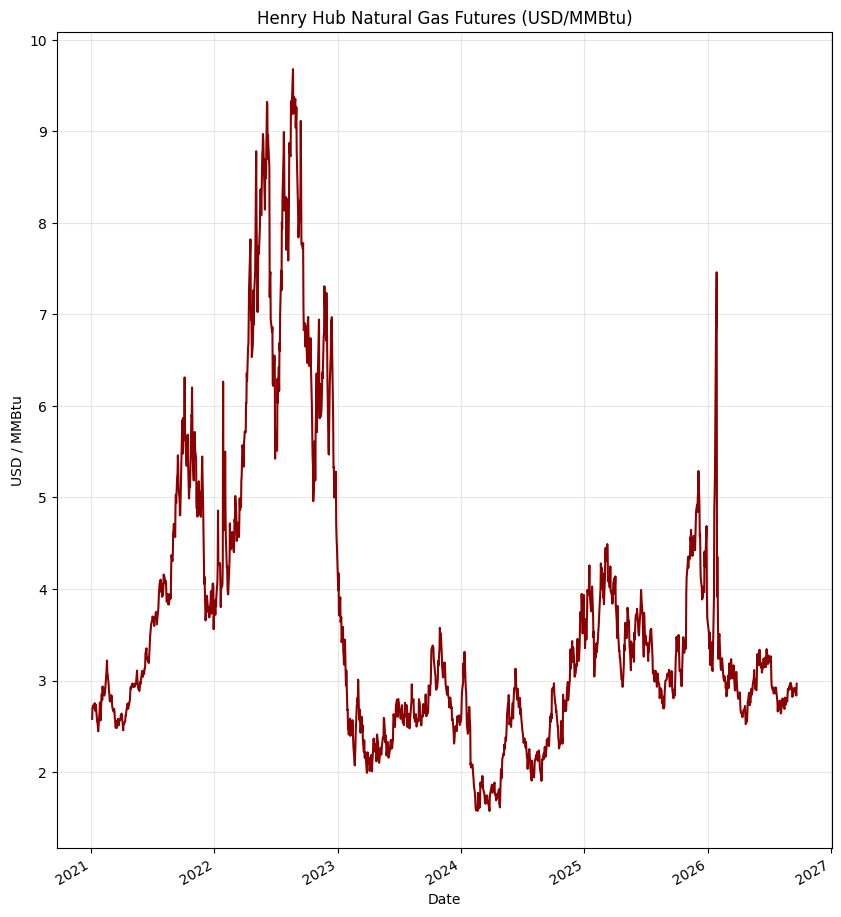

In [53]:
# Plot HH price history
import matplotlib.pyplot as plt

# Line chart shows volatility and 2022 price spike
hh_clean["HH_Close"].plot(figsize=(10, 12), title="Henry Hub Natural Gas Futures (USD/MMBtu)", color="darkred")
plt.ylabel("USD / MMBtu")
plt.grid(alpha=0.3)
plt.show()


### Output note
Chart shows 2022 spike near 9.68, then retreat to near 3. Confirms crisis regime in raw data.


In [54]:
# Download Dutch TTF futures (TTF=F) in EUR per MWh
# TTF is the European gas benchmark
ttf = yf.download("TTF=F", start="2021-01-01", end="2026-09-23", auto_adjust=True)

# Check size and preview raw TTF data
print(ttf.shape)
ttf.head()


/tmp/ipykernel_951/2714007668.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ttf = yf.download("TTF=F", start="2021-01-01", end="2026-09-23")
[*********************100%***********************]  1 of 1 completed

(1438, 5)


Price,Close,High,Low,Open,Volume
Ticker,TTF=F,TTF=F,TTF=F,TTF=F,TTF=F
Date,,,,,
2021-01-04,19.844999,20.299999,19.450001,19.450001,803
2021-01-05,18.004999,18.950001,17.924999,18.905001,510
2021-01-06,17.565001,18.520000,17.375000,17.875000,704
2021-01-07,19.305000,19.420000,18.275000,18.275000,183
2021-01-08,20.120001,20.700001,19.889999,20.400000,385


### Output note
1438 TTF bars. Values in tens confirm EUR per MWh. Early 2021 near 19.8 matches history.


In [55]:
# Review TTF structure, dates and missing values
print(f"Shape: {ttf.shape}")
print(f"Columns: {ttf.columns.to_list()}")
print(f"Range: Min => {ttf.index.min()} to Max => {ttf.index.max()}")

print(f"Head: {ttf.head(10)}")

# Keep only TTF close and simplify column name
ttf_clean = ttf[["Close"]].copy()
ttf_clean.columns = ["TTF_Close"]
# Forward fill small gaps from holidays or missing prints
ttf_clean = ttf_clean.ffill()

# Confirm cleaned shape, recent values and missing count
print(f"Shape: {ttf_clean.shape}")
print(f"Tail: {ttf_clean.tail(10)}")
print(f"Missing: {ttf.isna().sum()}")


Shape: (1438, 5)
Columns: [('Close', 'TTF=F'), ('High', 'TTF=F'), ('Low', 'TTF=F'), ('Open', 'TTF=F'), ('Volume', 'TTF=F')]
Range: Min => 2021-01-04 00:00:00 to Max => 2026-09-22 00:00:00
Head: Price           Close       High        Low       Open Volume
Ticker          TTF=F      TTF=F      TTF=F      TTF=F  TTF=F
Date                                                         
2021-01-04  19.844999  20.299999  19.450001  19.450001    803
2021-01-05  18.004999  18.950001  17.924999  18.905001    510
2021-01-06  17.565001  18.520000  17.375000  17.875000    704
2021-01-07  19.305000  19.420000  18.275000  18.275000    183
2021-01-08  20.120001  20.700001  19.889999  20.400000    385
2021-01-11  22.125000  22.540001  21.200001  21.350000    460
2021-01-12  26.155001  26.155001  23.200001  23.240000    135
2021-01-13  21.500000  23.900000  21.500000  23.475000    535
2021-01-14  21.334999  21.334999  20.320000  21.250000    341
2021-01-15  20.200001  20.400000  19.625000  20.100000    523


In [56]:
# Download EURUSD for TTF currency conversion
fx = yf.download("EURUSD=X", start="2021-01-01", end="2026-09-23", auto_adjust=True)
# Keep only FX close and rename for clarity
fx_clean = fx[["Close"]].copy()
fx_clean.columns = ["EURUSD"]
# Forward fill FX weekends to match gas trading days
fx_clean = fx_clean.ffill()

# Check shape and last FX prints
print(fx_clean.shape)
fx_clean.tail()


/tmp/ipykernel_951/1486600828.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  fx = yf.download("EURUSD=X", start="2021-01-01", end="2026-09-23")
[*********************100%***********************]  1 of 1 completed

(1488, 1)


,EURUSD
Date,
2026-09-16,1.153762
2026-09-17,1.146986
2026-09-18,1.147605
2026-09-21,1.147974
2026-09-22,1.146460


In [57]:
# Align HH, TTF and FX on common trading dates
# Inner join drops dates missing in any series
df = hh_clean.join(ttf_clean, how="inner").join(fx_clean, how="inner")

# Verify aligned sample size and date coverage
print(df.shape)
print(f"Date Range: ", df.index.min(), "to", df.index.max())
df.head()


(1437, 3)
Date Range:  2021-01-04 00:00:00 to 2026-09-22 00:00:00


,HH_Close,TTF_Close,EURUSD
Date,,,
2021-01-04,2.581,19.844999,1.225070
2021-01-05,2.702,18.004999,1.225160
2021-01-06,2.716,17.565001,1.230027
2021-01-07,2.729,19.305000,1.234111
2021-01-08,2.700,20.120001,1.227144


### Output note
1437 common dates after inner join. Small row loss is from mismatched US and EU holidays.


In [58]:
# Convert TTF from EUR per MWh to USD per MMBtu
# 1 MWh equals 3.412 MMBtu
MMBTU_PER_MWH = 3.412

# Divide by energy factor then apply FX rate
df["TTF_USD"] = df["TTF_Close"] / MMBTU_PER_MWH * df["EURUSD"]

# Compare HH and TTF level, range and quartiles
df[["HH_Close", "TTF_USD"]].describe()


,HH_Close,TTF_USD
count,1437.000000,1437.000000
mean,3.705644,18.362698
std,1.652969,13.173769
min,1.575000,5.499029
25%,2.662000,10.775222
50%,3.109000,13.042528
75%,4.140000,21.214089
max,9.680000,99.127183


### Output note
Common units achieved. HH mean 3.71 vs TTF mean 18.36. TTF max 99.13 matches Aug 2022 record. Premium confirms transport plus risk pricing.


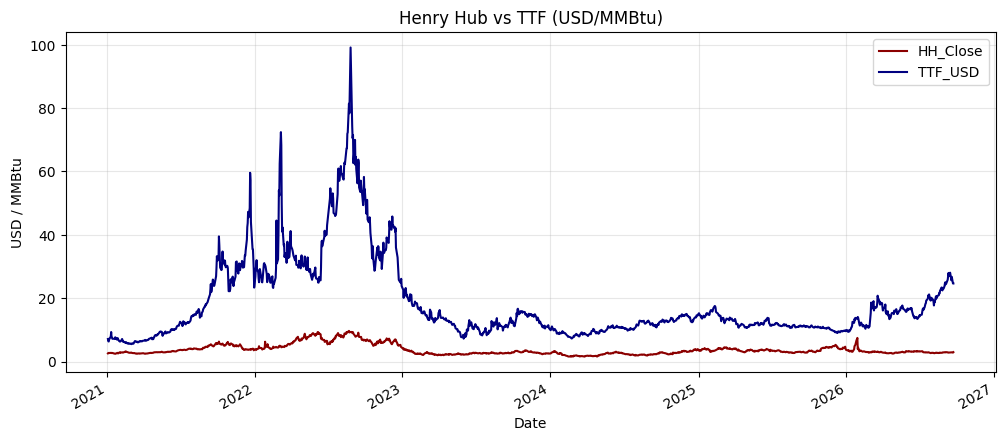

In [59]:
# Plot both benchmarks in common USD per MMBtu units
df[["HH_Close", "TTF_USD"]].plot(figsize=(12, 5), title="Henry Hub vs TTF (USD/MMBtu)", color=["darkred", "navy"]
)
plt.ylabel("USD / MMBtu")
plt.grid(alpha=0.3)
plt.show()


### Output note
TTF sits above HH throughout. Gap blows out in 2022, then narrows 2023 to 2025 and widens again in 2026.


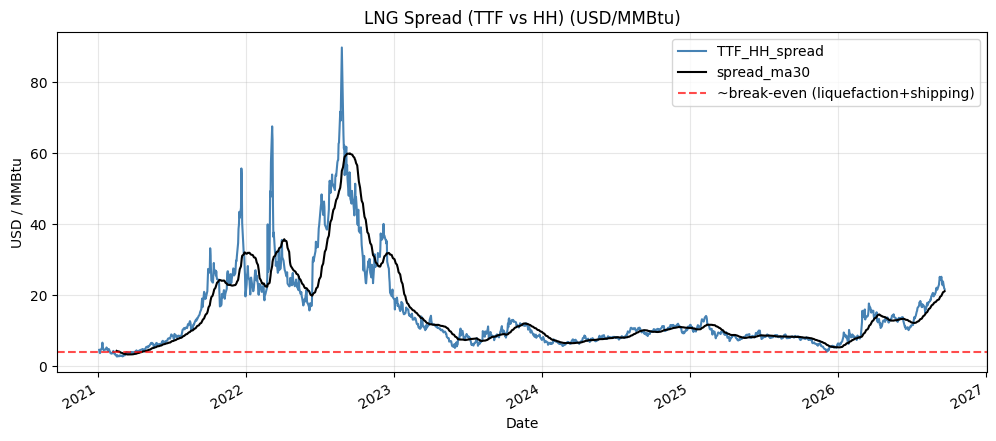

In [60]:
# Compute transatlantic LNG spread in USD per MMBtu
df["TTF_HH_spread"] = df["TTF_USD"] - df["HH_Close"]

# Add 30 day average to smooth daily noise
df["spread_ma30"] = df["TTF_HH_spread"].rolling(30).mean()

# Plot daily spread versus smoothed trend
df[["TTF_HH_spread", "spread_ma30"]].plot(figsize=(12, 5),
                                          title="LNG Spread (TTF vs HH) (USD/MMBtu)",
                                          color=["steelblue", "black"])

# Reference line for rough liquefaction plus shipping cost
plt.axhline(y=4, color="red", linestyle="--", alpha=0.7, label="~break-even (liquefaction+shipping)")
plt.ylabel("USD / MMBtu")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Output note
Daily spread volatile, 30 day trend clearer. Red line at 4 marks rough break even for liquefaction plus shipping. Most of sample sits above it.


In [61]:
# Isolate 2022 TTF minus HH spread for stress year review
df_2022 = df[df.index.year == 2022]["TTF_HH_spread"]

# Report months of widest and narrowest daily spread
print(f"Month: {df_2022.idxmax().month}, Spread: {df_2022.max()}")
print(f"Month: {df_2022.idxmin().month}, Spread: {df_2022.min()}")


Month: 8, Spread: 89.8311833165248
Month: 6, Spread: 15.651961513281531


### Output note
Aug 2022 most profitable at 89.83 daily max. Jun 2022 weakest at 15.65. August peak aligns with Europe restocking push.


In [62]:
# Flag days when smoothed spread covers transport cost
# Spread above 4 implies profitable US to Europe flow
df["arb_open"] = df["spread_ma30"] > 4

# Share of sample with open arbitrage window
print("Share of days with profitable US-Europe arb (30d MA): ",
      round(df["arb_open"].mean() * 100, 1), "%")

# Yearly mean, max and min spread to show regime shifts
df.groupby(df.index.year)["TTF_HH_spread"].agg("mean", "max", "min")


Share of days with profitable US-Europe arb (30d MA):  95.3 %


,TTF_HH_spread
Date,
2021,12.557015
2022,34.140530
2023,10.405952
2024,8.570002
2025,8.293791
2026,13.722869


### Output note
95.3 pct of days above break even on 30 day basis. Yearly mean peaks in 2022 at 34.14, normalizes to 8 to 10 in 2024 to 2025, then rises to 13.72 in 2026.


In [63]:
# Download JKM futures (JKM=F) for Asian LNG benchmark
# JKM is already quoted in USD per MMBtu
jkm = yf.download("JKM=F", start="2021-01-01", end="2026-09-23", auto_adjust=True)
print(jkm.shape)
jkm.head()


/tmp/ipykernel_951/3272236742.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  jkm = yf.download("JKM=F", start="2021-01-01", end="2026-09-23")
[*********************100%***********************]  1 of 1 completed

(1437, 5)


Price,Close,High,Low,Open,Volume
Ticker,JKM=F,JKM=F,JKM=F,JKM=F,JKM=F
Date,,,,,
2021-01-04,14.930,14.930,14.930,14.930,0
2021-01-05,15.105,15.105,15.105,15.105,0
2021-01-06,15.550,15.550,15.550,15.550,0
2021-01-07,17.250,17.250,17.250,17.250,0
2021-01-08,17.250,17.250,17.250,17.250,0


In [64]:
# Keep only JKM close and simplify column name
jkm_clean = jkm[["Close"]].copy()
jkm_clean.columns = ["JKM_Close"]   # already USD/MMBtu
# Forward fill gaps to align with HH and TTF calendar
jkm_clean = jkm_clean.ffill()

# Join JKM to main frame on common dates
df = df.join(jkm_clean, how="inner")
print(df.shape)
df[["HH_Close", "TTF_USD", "JKM_Close"]].tail()


(1435, 8)


,HH_Close,TTF_USD,JKM_Close
Date,,,
2026-09-16,2.891,26.385708,27.225000
2026-09-17,2.901,25.666674,26.750000
2026-09-18,2.912,26.745383,27.510000
2026-09-21,2.836,24.646108,25.990000
2026-09-22,2.965,24.642847,26.049999


### Output note
JKM already in USD per MMBtu, so no FX step needed. Final frame has 1435 common dates with HH, TTF and JKM aligned.


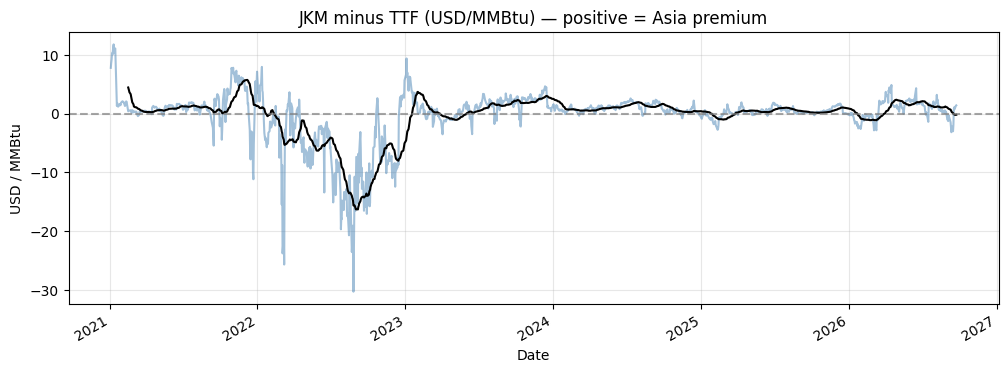

In [65]:
# Compute Asia versus Europe spread in USD per MMBtu
df['JKM_TTF_spread'] = df['JKM_Close'] - df['TTF_USD']
# Add 30 day average to highlight persistent premium
df['jkm_ttf_ma30'] = df['JKM_TTF_spread'].rolling(30).mean()

# Plot daily spread with trend and zero reference
df['JKM_TTF_spread'].plot(figsize=(12, 4), color='steelblue', alpha=0.5)
df['jkm_ttf_ma30'].plot(color='black')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
plt.title('JKM minus TTF (USD/MMBtu) - positive = Asia premium')
plt.ylabel('USD / MMBtu')
plt.grid(alpha=0.3)
plt.show()


### Output note
Positive values mean Asia premium and eastward pull. Negative values mean Europe premium and westward pull. Trend near zero in Sep 2026 means no strong directional pull.


In [66]:
# Yearly mean, min and max of JKM minus TTF spread
# Positive mean points to Asia premium, negative to Europe premium
df.groupby(df.index.year)['JKM_TTF_spread'].agg(['mean', 'min', 'max'])


,mean,min,max
Date,,,
2021,1.680160,-11.175484,11.797897
2022,-6.571522,-30.327180,7.964099
2023,1.323665,-3.514213,9.401008
2024,0.915922,-0.787528,2.592604
2025,0.323087,-2.750326,1.918393
2026,0.690528,-3.160473,4.881361


### Output note
2022 mean at minus 6.57 shows Europe premium during supply crisis. Other years show small Asia premium. Range narrows after 2023 as markets normalize.
